In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

## check loading data

In [3]:
shell_data=np.loadtxt('../shell_propagation/shell_evolution_deltat_1yr.txt')
time = shell_data[:,0] #s
rsh = shell_data[:,1] #cm
vsh = shell_data[:,2] #cm/s
deltav_1 = shell_data[:,3] #cm/s
deltav_2 = shell_data[:,4] #cm/s
rhofl_1 = shell_data[:,5] #g/cm^3
rhofl_2 = shell_data[:,6] #g/cm^3
# int_rhofl_1_sq_dr = shell_data[:,7] #g^3/cm^5 #once it's added

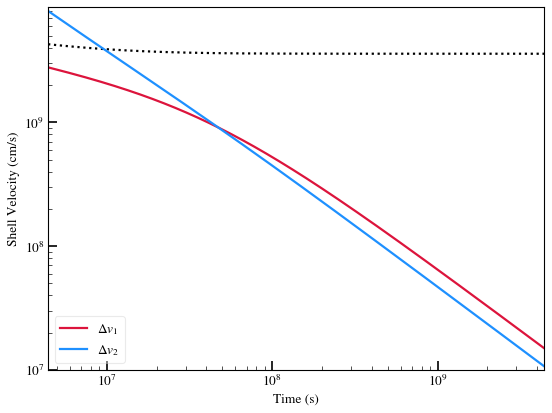

In [19]:
# plt.plot(time, rsh)
# plt.xlabel('Time (s)')
# plt.ylabel('Radius (cm)')

plt.plot(time, vsh,color='black',ls=':')
plt.plot(time, deltav_1,color='crimson',label=r'$\Delta v_{1}$')
plt.plot(time, deltav_2,color='dodgerblue',label=r'$\Delta v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

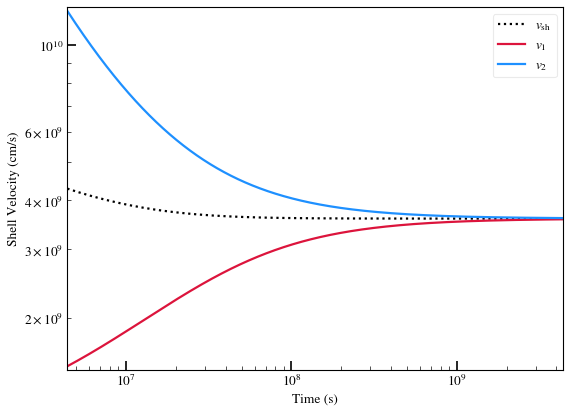

In [5]:
plt.plot(time, vsh,color='black',ls=':',label=r'$v_{\rm sh}$')
plt.plot(time, vsh-deltav_1,color='crimson',label=r'$v_{1}$')
plt.plot(time, deltav_2+vsh,color='dodgerblue',label=r'$v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

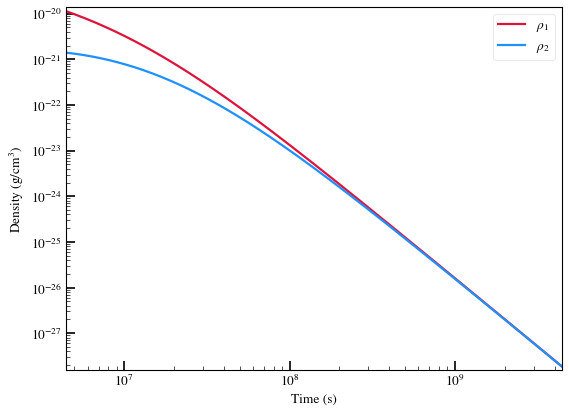

In [6]:
plt.plot(time,rhofl_1,color='crimson',label=r'$\rho_{1}$')
plt.plot(time,rhofl_2,color='dodgerblue',label=r'$\rho_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Density (g/cm$^3$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [7]:
'shell_evolution_deltat_1yr.txt'.split('.txt')

['shell_evolution_deltat_1yr', '']

## check loading shock_data.npz

In [12]:
shock_data = np.load('./evolve_spectrum_epsB_1e-2/shell_evolution_deltat_1yr/shock_data.npz')

In [13]:
shock_data.files

['times',
 'rsh_of_t',
 'vsh_of_t',
 'deltav1_of_t',
 'rho1_of_t',
 'deltav2_of_t',
 'rho2_of_t']

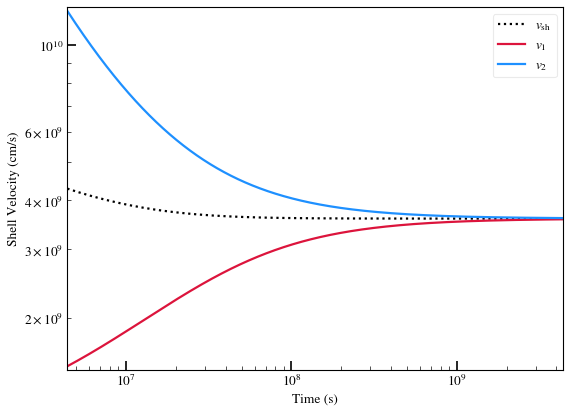

In [14]:
plt.plot(shock_data['times'], shock_data['vsh_of_t'],color='black',ls=':',label=r'$v_{\rm sh}$')
plt.plot(shock_data['times'], shock_data['vsh_of_t']-shock_data['deltav1_of_t'],color='crimson',label=r'$v_{1}$')
plt.plot(shock_data['times'], shock_data['deltav2_of_t']+shock_data['vsh_of_t'],color='dodgerblue',label=r'$v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

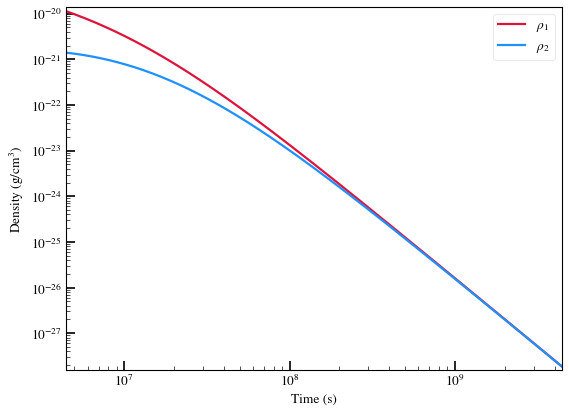

In [15]:
plt.plot(shock_data['times'], shock_data['rho1_of_t'],color='crimson',label=r'$\rho_{1}$')
plt.plot(shock_data['times'], shock_data['rho2_of_t'],color='dodgerblue',label=r'$\rho_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Density (g/cm$^3$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [16]:
shock_data['times']/secinyear

array([  0.14005557,   0.14045503,   0.14085513, ..., 139.46179455,
       139.60167089, 139.74168675])

In [17]:
p=3

def B(eps_B,rho,vel): #inputs in CGS
    return np.sqrt(8*np.pi*eps_B*rho*vel**2) #in Gauss
#assuming gamma_max -> infty, normalization of dn/dgamma = n0 * gamma^-p is:
def n0(eps_E,gamma_min,rho,vel,p=p): #this is number density for the energy distribution dn/dgamma
    return eps_E*((p-2)*gamma_min**(p-2))*rho*vel**2/(m_e.cgs.value*c.cgs.value**2)

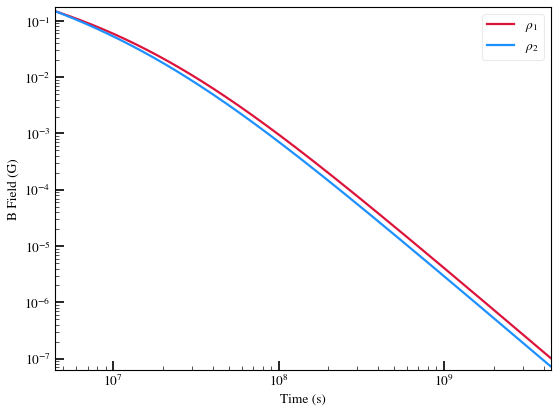

In [18]:
plt.plot(shock_data['times'],B(1e-2,shock_data['rho1_of_t'],shock_data['deltav1_of_t']),color='crimson',label=r'$\rho_{1}$')
plt.plot(shock_data['times'],B(1e-2,shock_data['rho2_of_t'],shock_data['deltav2_of_t']),color='dodgerblue',label=r'$\rho_{2}$')

plt.xlabel('Time (s)')
plt.ylabel('B Field (G)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

# check loading spectrum data